In this notebook we compare the Classical Fidelity among the different methods (MLE, VAE) as a function of different
number of samples $N_{\text{sample}}$  used to train/fit the models.

We study and compare 3 different states, with different levels and types of entanglement:
- *Greenberger–Horne–Zeilinger* (GHZ) 3-qubit state
- *Wolfgang Dür* (W) 3-qubit state
- "*product plus*" ($\ket{+++}$) 3-qubit state

# import

In [1]:
# general import: 
import sys
import time
import os
import gc
import glob
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# quantum import:
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city, plot_state_hinton, plot_state_qsphere

In [3]:
# ML import:
import tensorflow as tf
import keras
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import sklearn
from sklearn.model_selection import train_test_split

In [4]:
# custom helper and libraries:
sys.path.append('../src')
from povm_sampling import *
from statesprep import *
from vae import *
from plots import *
from utils import *
from mle import *

In [5]:
# repo directory
PROJECT_DIR = Path.cwd().parent   

# figs directory
FIGS_DIR = PROJECT_DIR / 'figs'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# MLE data directory
DATA_DIR = PROJECT_DIR / 'data' / 'Comparative_analysis'
DATA_DIR.mkdir(parents=True, exist_ok=True)

# $F_c$ - $N_{sample}$ data generation

In [ ]:
# helper functions

# wrapper of sample_povm for a better comprension in the for-cicle
def generate_dataset(p_exact, seed_data, n_samples=500):
    samples = sample_povm(p_exact, n_samples, seed=seed_data)
    return samples

# function to run a single reconstruction via MLE
def fit_mle(p_exact, samples, N):
    nll = make_nll(samples, N)

    dim = 2**N
    init_rho = np.eye(dim, dtype=complex) / dim
    p0 = rho_to_params(init_rho, N)

    m = Minuit(nll, *p0)
    m.errordef = Minuit.LIKELIHOOD
    m.print_level = 0
    m.migrad()
    if not m.valid:
        m.migrad()                                

    rho_mle = params_to_rho(np.array(m.values), N)
    p_mle = povm_probability(rho_mle, N)
    fc    = classical_fidelity(p_exact, p_mle)

    return float(fc)

# function to run a single reconstruction via VAE
def fit_vae(p_exact, samples, N, n_gen=50_000):
    onehot_samples = samples_to_onehot(samples, N)

    X_train, X_test = train_test_split(onehot_samples, test_size=0.2, random_state=42)

    LATENT_DIM = 16
    HIDDEN_DIM = 96
    WARMUP_EPOCHS = 50
    TOTAL_EPOCHS = 500
    BATCH_SIZE = 100
    LEARNING_RATE = 1e-3
    BETA_MAX = 0.85

    vae = VAE(n_qubits=N, latent_dim=LATENT_DIM, hidden=HIDDEN_DIM)
    vae.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))
    vae.build(input_shape=(None, 4*N))

    callbacks = [
        KLWarmup(beta_max=BETA_MAX, warmup_epochs=WARMUP_EPOCHS),
        keras.callbacks.EarlyStopping(
            monitor='val_reconstruction_loss', mode='min', patience=50,
            restore_best_weights=True, start_from_epoch=WARMUP_EPOCHS),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_reconstruction_loss', mode='min',
            factor=0.5, patience=20, min_lr=1e-6),
    ]
    vae.fit(X_train, X_train, epochs=TOTAL_EPOCHS, batch_size=BATCH_SIZE,
            validation_data=(X_test, X_test), callbacks=callbacks, verbose=0)

    p_vae = vae.predict_dist(n_samples=n_gen, batch_size=50_000)
    fc = classical_fidelity(p_exact, p_vae)


    # delete trained model and clear the memory
    del vae
    keras.backend.clear_session()
    gc.collect()

    return float(fc)

We study GHZ, W and $\ket{+++}$ using the relative function *create_ghz_state()*, *create_w_state()*, *create_plus_state()*

In [ ]:
# state simulation 
N = 3       # n qubits
qc = create_ghz_state(N)    # other functions create_w_state(N), create_plus_state(N)
rho_true = DensityMatrix(qc)
p_exact = povm_probability(rho_true.data, N)

We study each state considering 100, 200, 500, 1000, 5000, 10000 samples and evaluating B=50 different datasets (like bootstrap) in order to estimate the 95% percentile of Fidelity distributions.

In [ ]:
B = 50             # number of independent datasets
N_GEN = 100_000    # number of samples generated by VAE to estimate p_vae (>> n_samples, to dominate shot noise)
n_samples = 10000  # in [100, 200, 500, 1000, 5000, 10000]

rows = []
for b in range(B):
    samples = generate_dataset(p_exact=p_exact, seed_data=42 + b, n_samples=n_samples)
    fc_m = fit_mle(p_exact, samples, N)                                                  
    fc_v = fit_vae(p_exact, samples, N, n_gen=N_GEN)     

    rows.append(dict(method='MLE', b=b, N=n_samples, F_c=fc_m))
    rows.append(dict(method='VAE', b=b, N=n_samples, F_c=fc_v))

    if b % 1 == 0:
        print(f"{b+1}/{B}  F_c: MLE={fc_m:.4f}  VAE={fc_v:.4f}")

# Only one csv, each rows contains method (MLE; VAE) and b index
df = pd.DataFrame(rows)
df.to_csv(DATA_DIR / f'risultati_shot_N{n_samples}_B{B}_ghz.csv', index=False)
print("\nSalvato. Righe:", len(df))

1/50  F_c: MLE=0.9997  VAE=0.9900
2/50  F_c: MLE=0.9998  VAE=0.9910
3/50  F_c: MLE=0.9996  VAE=0.9912
4/50  F_c: MLE=0.9996  VAE=0.9913
5/50  F_c: MLE=0.9997  VAE=0.9920
6/50  F_c: MLE=0.9994  VAE=0.9910
7/50  F_c: MLE=0.9997  VAE=0.9883
8/50  F_c: MLE=0.9998  VAE=0.9915
9/50  F_c: MLE=0.9995  VAE=0.9910
10/50  F_c: MLE=0.9998  VAE=0.9909
11/50  F_c: MLE=0.9996  VAE=0.9917
12/50  F_c: MLE=0.9997  VAE=0.9908
13/50  F_c: MLE=0.9996  VAE=0.9913
14/50  F_c: MLE=0.9995  VAE=0.9886
15/50  F_c: MLE=0.9997  VAE=0.9906
16/50  F_c: MLE=0.9996  VAE=0.9918
17/50  F_c: MLE=0.9997  VAE=0.9909
18/50  F_c: MLE=0.9997  VAE=0.9907
19/50  F_c: MLE=0.9996  VAE=0.9916
20/50  F_c: MLE=0.9997  VAE=0.9910
21/50  F_c: MLE=0.9997  VAE=0.9891
22/50  F_c: MLE=0.9997  VAE=0.9921
23/50  F_c: MLE=0.9997  VAE=0.9909
24/50  F_c: MLE=0.9996  VAE=0.9913
25/50  F_c: MLE=0.9996  VAE=0.9916
26/50  F_c: MLE=0.9997  VAE=0.9902
27/50  F_c: MLE=0.9998  VAE=0.9921
28/50  F_c: MLE=0.9998  VAE=0.9893
29/50  F_c: MLE=0.9997  VAE=0

# GHZ3

GHZ 3-qubit state: $\space \frac{1}{\sqrt{2}}(\ket{000} + \ket{111})$

The GHZ state is a Genuinely Multipartite Maximally Entangled state, meaning that all qubits share non-local global correlations, such that a local measurement outcome on any single qubit influences the outcomes of all the others.

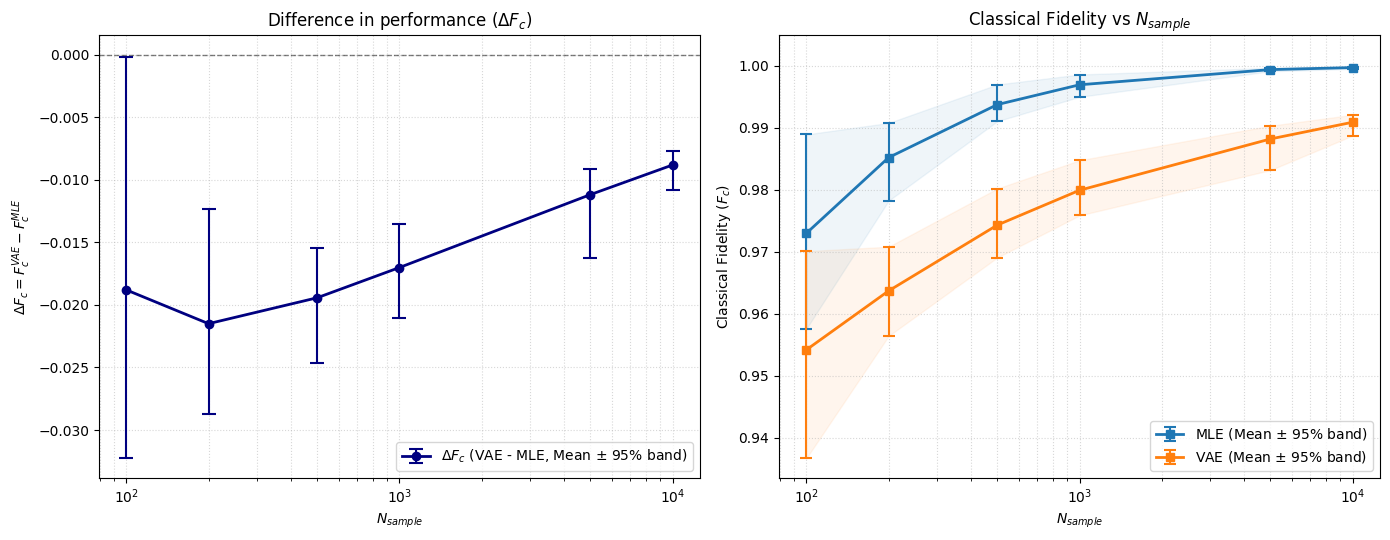

In [12]:
# -- load --
paths = sorted(DATA_DIR.glob("risultati_shot_N*_B50_ghz.csv"))
df_cmp = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True).rename(columns={'N': 'N_sample'})

# pivot table to compute Delta (VAE - MLE)
df_piv = df_cmp.pivot_table(index=['N_sample', 'b'], columns='method', values='F_c').reset_index()
df_piv['Delta'] = df_piv['VAE'] - df_piv['MLE']

n_vals = sorted(df_cmp.N_sample.unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
# fig, ax2 = plt.subplots(figsize=(8, 5))


# -- left plot --
g_delta = df_piv.groupby('N_sample')['Delta']

# 95% distribution band
low_err_d = g_delta.mean().values - g_delta.quantile(0.025).values
high_err_d = g_delta.quantile(0.975).values - g_delta.mean().values
yerr_d = np.array([low_err_d, high_err_d])

ax1.axhline(0, color='black', lw=1, ls='--', alpha=0.5)

# error bar: 95% band
ax1.errorbar(n_vals, g_delta.mean().values, yerr=yerr_d,
             fmt='o-', color='navy', lw=2, elinewidth=1.5, capsize=5, capthick=1.5, label='$\\Delta F_c$ (VAE - MLE, Mean $\\pm$ 95% band)')

ax1.set_xlabel(r"$N_{sample}$")
ax1.set_ylabel(r"$\Delta F_c = F_c^{VAE} - F_c^{MLE}$")
ax1.set_xscale('log')
ax1.legend(loc='lower right')
ax1.grid(True, which='both', ls=':', alpha=0.5)


# -- right plot --
colors = {'MLE': 'C0', 'VAE': 'C1'}
# colors = {'MLE': 'blue', 'VAE': 'orange'} --> others graph config

for met in ['MLE', 'VAE']:
    g_fc = df_cmp[df_cmp.method == met].groupby('N_sample')['F_c']
    ax2.fill_between(n_vals, g_fc.quantile(0.025).values, g_fc.quantile(0.975).values,
                     color=colors[met], alpha=0.07)

# error bar: 95% band
for met in ['MLE', 'VAE']:
    g_fc = df_cmp[df_cmp.method == met].groupby('N_sample')['F_c']
    
    low_err_f = g_fc.mean().values - g_fc.quantile(0.025).values
    high_err_f = g_fc.quantile(0.975).values - g_fc.mean().values
    yerr_f = np.array([low_err_f, high_err_f])
    
    ax2.errorbar(n_vals, g_fc.mean().values, yerr=yerr_f,
                 fmt='s-', color=colors[met], lw=2, elinewidth=1.5, capsize=4, capthick=1.5, 
                 label=f'{met} (Mean $\\pm$ 95% band)')

ax2.set_ylim(None, 1.005)
ax2.set_xlabel(r"$N_{sample}$")
ax2.set_ylabel(r"Classical Fidelity ($F_c$)")
ax2.set_xscale('log')

# legend
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, labels, loc='lower right') 
ax2.grid(True, which='both', ls=':', alpha=0.5)


# -- titles --
# fig.suptitle("GHZ 3-qubit state reconstruction", y=0.98)
ax1.set_title("Difference in performance ($\\Delta F_c$)") #[2.5% - 97.5% percentile band]
ax2.set_title("Classical Fidelity vs $N_{sample}$")


fig.tight_layout()

# -- save fig --
# fig.savefig(FIGS_DIR / 'Comp_ghz3_fideliy.svg', bbox_inches='tight')

plt.show()

# W3

W 3-qubit state: $\space \frac{1}{\sqrt{3}}(\ket{100} + \ket{010} + \ket{001})$

The W state is a Highly Robust Multipartite Entangled state, meaning that all qubits share distributed local correlations, such that the entanglement exhibits maximum resilience against particle loss and remains highly preserved among the surviving qubits if any single one is lost or measured.

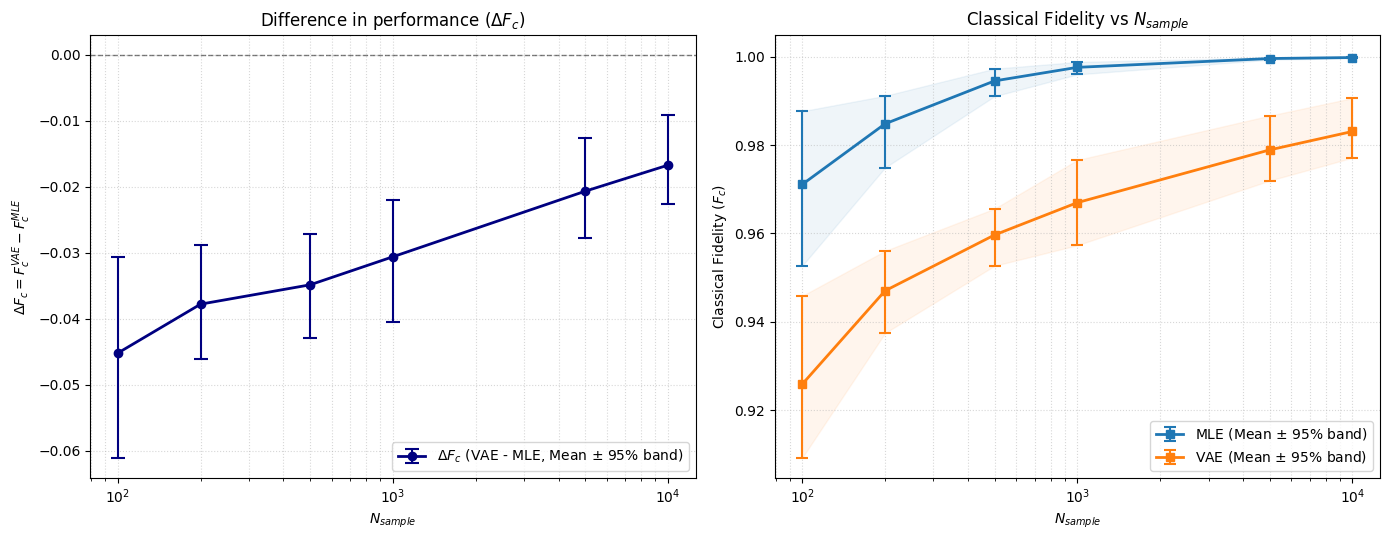

In [14]:
# -- load --
paths = sorted(DATA_DIR.glob("risultati_shot_N*_B50_w.csv"))
df_cmp = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True).rename(columns={'N': 'N_sample'})

# pivot table to compute Delta (VAE - MLE)
df_piv = df_cmp.pivot_table(index=['N_sample', 'b'], columns='method', values='F_c').reset_index()
df_piv['Delta'] = df_piv['VAE'] - df_piv['MLE']

n_vals = sorted(df_cmp.N_sample.unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
# fig, ax2 = plt.subplots(figsize=(8, 5))


# -- left plot --
g_delta = df_piv.groupby('N_sample')['Delta']

# 95% distribution band
low_err_d = g_delta.mean().values - g_delta.quantile(0.025).values
high_err_d = g_delta.quantile(0.975).values - g_delta.mean().values
yerr_d = np.array([low_err_d, high_err_d])

ax1.axhline(0, color='black', lw=1, ls='--', alpha=0.5)

# error bar: 95% band
ax1.errorbar(n_vals, g_delta.mean().values, yerr=yerr_d,
             fmt='o-', color='navy', lw=2, elinewidth=1.5, capsize=5, capthick=1.5, label='$\\Delta F_c$ (VAE - MLE, Mean $\\pm$ 95% band)')

ax1.set_xlabel(r"$N_{sample}$")
ax1.set_ylabel(r"$\Delta F_c = F_c^{VAE} - F_c^{MLE}$")
ax1.set_xscale('log')
ax1.legend(loc='lower right')
ax1.grid(True, which='both', ls=':', alpha=0.5)


# -- right plot --
colors = {'MLE': 'C0', 'VAE': 'C1'}
# colors = {'MLE': 'blue', 'VAE': 'orange'} --> others graph config

for met in ['MLE', 'VAE']:
    g_fc = df_cmp[df_cmp.method == met].groupby('N_sample')['F_c']
    ax2.fill_between(n_vals, g_fc.quantile(0.025).values, g_fc.quantile(0.975).values,
                     color=colors[met], alpha=0.07)

# error bar: 95% band
for met in ['MLE', 'VAE']:
    g_fc = df_cmp[df_cmp.method == met].groupby('N_sample')['F_c']
    
    low_err_f = g_fc.mean().values - g_fc.quantile(0.025).values
    high_err_f = g_fc.quantile(0.975).values - g_fc.mean().values
    yerr_f = np.array([low_err_f, high_err_f])
    
    ax2.errorbar(n_vals, g_fc.mean().values, yerr=yerr_f,
                 fmt='s-', color=colors[met], lw=2, elinewidth=1.5, capsize=4, capthick=1.5, 
                 label=f'{met} (Mean $\\pm$ 95% band)')

ax2.set_ylim(None, 1.005)
ax2.set_xlabel(r"$N_{sample}$")
ax2.set_ylabel(r"Classical Fidelity ($F_c$)")
ax2.set_xscale('log')

# legend
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, labels, loc='lower right') 
ax2.grid(True, which='both', ls=':', alpha=0.5)


# -- titles --
# fig.suptitle("W 3-qubit state reconstruction", y=0.98)
ax1.set_title("Difference in performance ($\\Delta F_c$)") #[2.5% - 97.5% percentile band]
ax2.set_title("Classical Fidelity vs $N_{sample}$")


fig.tight_layout()

# -- save fig --
# fig.savefig(FIGS_DIR / 'Comp_w3_fidelity.svg', bbox_inches='tight')

plt.show()

# $\ket{+++}$

Product Plus 3-qubit state: $\space \ket{+++} = \frac{1}{2\sqrt{2}}(\ket{0} + \ket{1})(\ket{0} + \ket{1})(\ket{0} + \ket{1})$

The product plus state is a Completely Unentangled Separable state, meaning that all qubits are statistically independent, such that a local measurement outcome on any single qubit carries zero information and has absolutely no influence on the outcomes of the others.

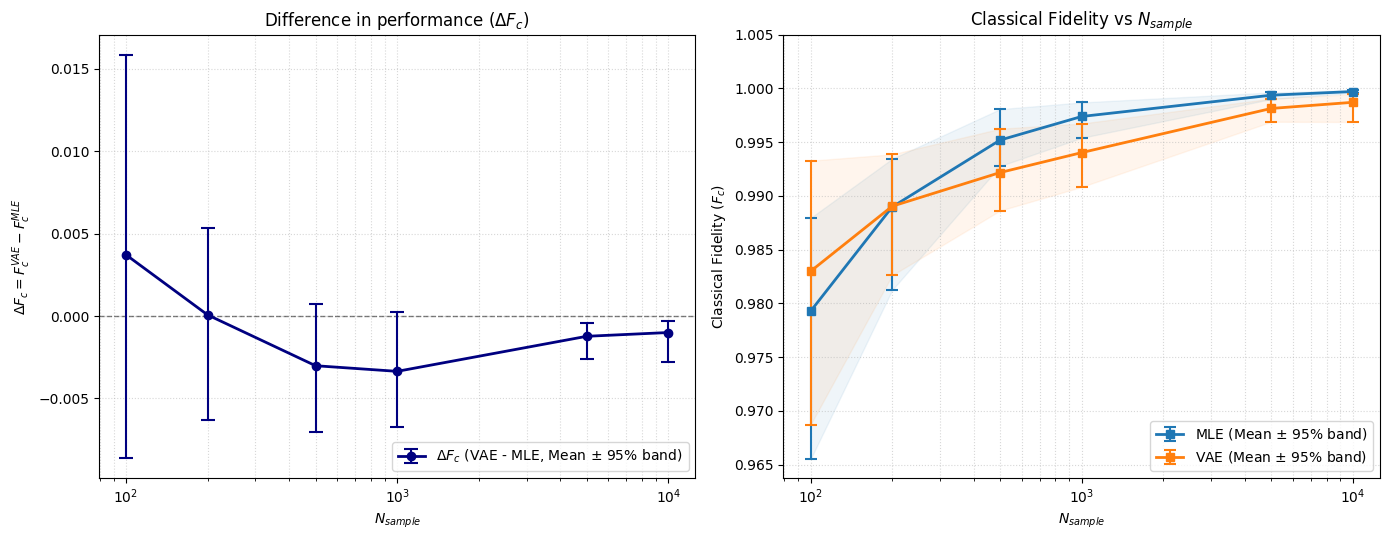

In [16]:
# -- load --
paths = sorted(DATA_DIR.glob("risultati_shot_N*_B50_plus.csv"))
df_cmp = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True).rename(columns={'N': 'N_sample'})

# pivot table to compute Delta (VAE - MLE)
df_piv = df_cmp.pivot_table(index=['N_sample', 'b'], columns='method', values='F_c').reset_index()
df_piv['Delta'] = df_piv['VAE'] - df_piv['MLE']

n_vals = sorted(df_cmp.N_sample.unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
# fig, ax2 = plt.subplots(figsize=(8, 5))


# -- left plot --
g_delta = df_piv.groupby('N_sample')['Delta']

# 95% distribution band
low_err_d = g_delta.mean().values - g_delta.quantile(0.025).values
high_err_d = g_delta.quantile(0.975).values - g_delta.mean().values
yerr_d = np.array([low_err_d, high_err_d])

ax1.axhline(0, color='black', lw=1, ls='--', alpha=0.5)

# error bar: 95% band
ax1.errorbar(n_vals, g_delta.mean().values, yerr=yerr_d,
             fmt='o-', color='navy', lw=2, elinewidth=1.5, capsize=5, capthick=1.5, label='$\\Delta F_c$ (VAE - MLE, Mean $\\pm$ 95% band)')

ax1.set_xlabel(r"$N_{sample}$")
ax1.set_ylabel(r"$\Delta F_c = F_c^{VAE} - F_c^{MLE}$")
ax1.set_xscale('log')
ax1.legend(loc='lower right')
ax1.grid(True, which='both', ls=':', alpha=0.5)


# -- right plot --
colors = {'MLE': 'C0', 'VAE': 'C1'}
# colors = {'MLE': 'blue', 'VAE': 'orange'} --> others graph config

for met in ['MLE', 'VAE']:
    g_fc = df_cmp[df_cmp.method == met].groupby('N_sample')['F_c']
    ax2.fill_between(n_vals, g_fc.quantile(0.025).values, g_fc.quantile(0.975).values,
                     color=colors[met], alpha=0.07)

# error bar: 95% band
for met in ['MLE', 'VAE']:
    g_fc = df_cmp[df_cmp.method == met].groupby('N_sample')['F_c']
    
    low_err_f = g_fc.mean().values - g_fc.quantile(0.025).values
    high_err_f = g_fc.quantile(0.975).values - g_fc.mean().values
    yerr_f = np.array([low_err_f, high_err_f])
    
    ax2.errorbar(n_vals, g_fc.mean().values, yerr=yerr_f,
                 fmt='s-', color=colors[met], lw=2, elinewidth=1.5, capsize=4, capthick=1.5, 
                 label=f'{met} (Mean $\\pm$ 95% band)')

ax2.set_ylim(None, 1.005)
ax2.set_xlabel(r"$N_{sample}$")
ax2.set_ylabel(r"Classical Fidelity ($F_c$)")
ax2.set_xscale('log')

# legend
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, labels, loc='lower right') 
ax2.grid(True, which='both', ls=':', alpha=0.5)


# -- titles --
# fig.suptitle(r"$|+++\rangle$ 3-qubit state reconstruction", y=0.98)
ax1.set_title("Difference in performance ($\\Delta F_c$)") #[2.5% - 97.5% percentile band]
ax2.set_title("Classical Fidelity vs $N_{sample}$")


fig.tight_layout()

# -- save fig --
# fig.savefig(FIGS_DIR / 'Comp_plus_fideliy.svg', bbox_inches='tight')

plt.show()